<a href="https://colab.research.google.com/github/soyeon24/cloudGPI/blob/main/Eye2sky_withtest_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 파일 직접 업로드
from google.colab import files
uploaded = files.upload()  # 실행하면 파일 선택창 뜸


Saving OLCLO.cleaned.nc to OLCLO.cleaned.nc


In [2]:
!pip install -q netCDF4 xarray

import xarray as xr

ds = xr.open_dataset('OLCLO.cleaned.nc')
print(ds)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 92.3 MB/s eta 0:00:00
<xarray.Dataset> Size: 55MB
Dimensions:       (time: 525600)
Coordinates:
  * time          (time) datetime64[ns] 4MB 2022-04-01T00:01:00 ... 2023-04-01
    latitude      float64 8B ...
    longitude     float64 8B ...
    elevation     int64 8B ...
Data variables: (12/14)
    GTI_30_180    (time) float64 4MB ...
    cDNI          (time) float64 4MB ...
    RH            (time) float64 4MB ...
    cGHI          (time) float64 4MB ...
    turbidity     (time) float64 4MB ...
    SAZ           (time) float64 4MB ...
    ...            ...
    T             (time) float64 4MB ...
    DHI           (time) float64 4MB ...
    cDHI          (time) float64 4MB ...
    SZA           (time) float64 4MB ...
    station_name  <U5 20B ...
    crs           int64 8B ...
Attributes: (12/36)
    grid_mapping_name:            latitude_longitude
   

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Dataset → DataFrame 변환
df = ds[['cGHI', 'DHI', 'cDNI', 'SZA']].to_dataframe()
print(df.shape)
print(df.head(10))
print(df.describe())


(525600, 7)
                     cGHI  DHI  cDNI         SZA  latitude  longitude  \
time                                                                    
2022-04-01 00:01:00   0.0  0.0  -0.0  122.073177    53.112    8.21004   
2022-04-01 00:02:00   0.0  0.0  -0.0  122.049747    53.112    8.21004   
2022-04-01 00:03:00   0.0  0.0  -0.0  122.025560    53.112    8.21004   
2022-04-01 00:04:00   0.0  0.0  -0.0  122.000617    53.112    8.21004   
2022-04-01 00:05:00   0.0  0.0  -0.0  121.974918    53.112    8.21004   
2022-04-01 00:06:00   0.0  0.0  -0.0  121.948466    53.112    8.21004   
2022-04-01 00:07:00   0.0  0.0  -0.0  121.921260    53.112    8.21004   
2022-04-01 00:08:00   0.0  0.0  -0.0  121.893303    53.112    8.21004   
2022-04-01 00:09:00   0.0  0.0  -0.0  121.864595    53.112    8.21004   
2022-04-01 00:10:00   0.0  0.0  -0.0  121.835137    53.112    8.21004   

                     elevation  
time                            
2022-04-01 00:01:00         14  
2022-04-01 0

전체: 525,600개 → 낮시간: 236,343개


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


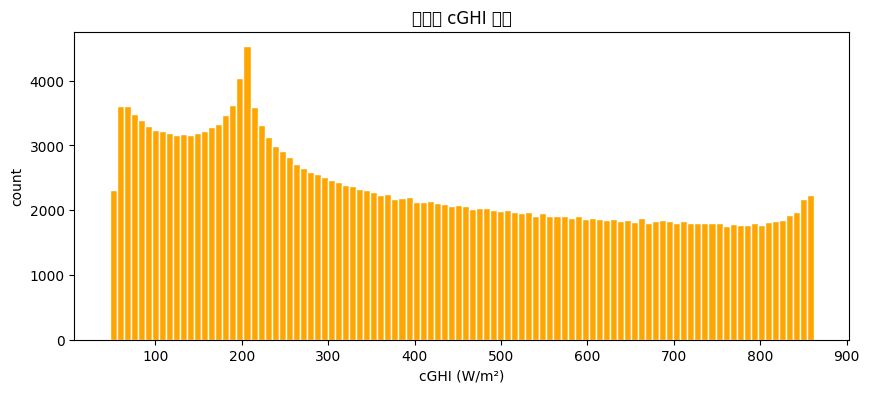


클래스 분포:
  low    (0~200):   61,924개 (26.2%)
  medium (200~600): 114,835개 (48.6%)
  high   (600+):    59,584개 (25.2%)


In [4]:
# 낮시간만 필터링 (SZA < 85도 = 태양이 충분히 떠있는 시간)
df_day = df[df['SZA'] < 85].copy()
print(f"전체: {len(df):,}개 → 낮시간: {len(df_day):,}개")

# cGHI 분포 확인
plt.figure(figsize=(10, 4))
plt.hist(df_day['cGHI'], bins=100, color='orange', edgecolor='white')
plt.xlabel('cGHI (W/m²)')
plt.ylabel('count')
plt.title('낮시간 cGHI 분포')
plt.show()

# 3단계 라벨 생성
# low / medium / high 기준 — 분포 보고 조정 가능
LOW_THR  = 200   # W/m²
HIGH_THR = 600   # W/m²

def ghi_to_label(ghi):
    if ghi < LOW_THR:  return 0  # low
    if ghi < HIGH_THR: return 1  # medium
    return 2                      # high

df_day['label'] = df_day['cGHI'].apply(ghi_to_label)

# 클래스 분포 확인
counts = df_day['label'].value_counts().sort_index()
print("\n클래스 분포:")
print(f"  low    (0~200):   {counts[0]:,}개 ({counts[0]/len(df_day)*100:.1f}%)")
print(f"  medium (200~600): {counts[1]:,}개 ({counts[1]/len(df_day)*100:.1f}%)")
print(f"  high   (600+):    {counts[2]:,}개 ({counts[2]/len(df_day)*100:.1f}%)")


In [5]:
import os
import urllib.request
import warnings
from datetime import datetime, timedelta

START_DATE = "2022-04-01"
END_DATE   = "2022-04-05"
SITES      = ["OLCLO"]

URL        = "https://eye2sky.de/data/asi/imgs"
TARGET_URL = URL + "/{dt:%Y/%m/%d}/ASI_{dt:%Y%m%d}_{stn}.zip"
LOCAL_FILENAME = os.path.join("Eye2Sky", "{dt:%Y/%m/%d}", "ASI_{dt:%Y%m%d}_{stn}.zip")

START_DATE = datetime.strptime(START_DATE, "%Y-%m-%d")
END_DATE   = datetime.strptime(END_DATE,   "%Y-%m-%d")
DATES      = [START_DATE + timedelta(days=x) for x in range((END_DATE - START_DATE).days + 1)]

print(f"총 {len(DATES)}일치 다운로드 시작")

for dt in DATES:
    for site in SITES:
        url   = TARGET_URL.format(stn=site, dt=dt)
        fname = LOCAL_FILENAME.format(stn=site, dt=dt)
        os.makedirs(os.path.dirname(fname), exist_ok=True)
        print(f"다운로드 중: {dt:%Y-%m-%d} {site}")
        try:
            urllib.request.urlretrieve(url, fname)
        except urllib.error.HTTPError as e:
            warnings.warn(f"없는 파일: {url}")
            continue

print("완료!")

총 5일치 다운로드 시작
다운로드 중: 2022-04-01 OLCLO
다운로드 중: 2022-04-02 OLCLO
다운로드 중: 2022-04-03 OLCLO
다운로드 중: 2022-04-04 OLCLO
다운로드 중: 2022-04-05 OLCLO
완료!


In [6]:
import zipfile, glob

zip_files = glob.glob("Eye2Sky/**/*.zip", recursive=True)
print(f"zip 파일 {len(zip_files)}개 발견")

for zf in zip_files:
    extract_dir = zf.replace(".zip", "")
    with zipfile.ZipFile(zf, 'r') as z:
        z.extractall(extract_dir)
        print(f"압축 해제: {extract_dir}")

zip 파일 5개 발견
압축 해제: Eye2Sky/2022/04/01/ASI_20220401_OLCLO
압축 해제: Eye2Sky/2022/04/05/ASI_20220405_OLCLO
압축 해제: Eye2Sky/2022/04/04/ASI_20220404_OLCLO
압축 해제: Eye2Sky/2022/04/02/ASI_20220402_OLCLO
압축 해제: Eye2Sky/2022/04/03/ASI_20220403_OLCLO


In [7]:
img_files = glob.glob("Eye2Sky/**/*.jpg", recursive=True)
print(f"이미지 {len(img_files)}개")
print(img_files[:5])  # 샘플 확인

이미지 8041개
['Eye2Sky/2022/04/01/ASI_20220401_OLCLO/OLCLO/2022/04/01/10/20220401100600_160.jpg', 'Eye2Sky/2022/04/01/ASI_20220401_OLCLO/OLCLO/2022/04/01/10/20220401103300_160.jpg', 'Eye2Sky/2022/04/01/ASI_20220401_OLCLO/OLCLO/2022/04/01/10/20220401103530_160.jpg', 'Eye2Sky/2022/04/01/ASI_20220401_OLCLO/OLCLO/2022/04/01/10/20220401104730_160.jpg', 'Eye2Sky/2022/04/01/ASI_20220401_OLCLO/OLCLO/2022/04/01/10/20220401105630_160.jpg']


In [8]:
#import urllib.request

#url = "https://eye2sky.de/data/asi/imgs/2022/04/01/ASI_20220401_OLWIN.zip"
#try:
#    resp = urllib.request.urlopen(url)
#    print(f"✅ OLWIN 이미지 있음! {len(resp.read())/1024/1024:.1f} MB")
#except Exception as e:
#    print(f"❌ 없음: {e}")

In [9]:
import urllib.request

url = "https://zenodo.org/records/12804613/files/OLWIN.zip?download=1"
fname = "OLWIN.zip"

print("OLWIN 광량 데이터 다운로드 중... (약 37MB)")
urllib.request.urlretrieve(url, fname)
print("완료!")

OLWIN 광량 데이터 다운로드 중... (약 37MB)
완료!


In [10]:
import zipfile

with zipfile.ZipFile("OLWIN.zip", 'r') as z:
    print(z.namelist())

['data/', 'data/OLWIN.flagged.nc', 'data/OLWIN.cleaned.nc', 'near_horizon.csv', 'near_horizon.png', 'QC_OLWIN.pdf']


In [11]:
import zipfile, os

with zipfile.ZipFile("OLWIN.zip", 'r') as z:
    z.extractall("OLWIN")

# 경로 확인
for root, dirs, files in os.walk("OLWIN"):
    for f in files:
        print(os.path.join(root, f))

OLWIN/near_horizon.csv
OLWIN/near_horizon.png
OLWIN/QC_OLWIN.pdf
OLWIN/data/OLWIN.cleaned.nc
OLWIN/data/OLWIN.flagged.nc


In [12]:
import xarray as xr

ds = xr.open_dataset("OLWIN/data/OLWIN.cleaned.nc")
print(ds)


<xarray.Dataset> Size: 55MB
Dimensions:       (time: 525600)
Coordinates:
  * time          (time) datetime64[ns] 4MB 2022-04-01T00:01:00 ... 2023-04-01
    latitude      float64 8B ...
    longitude     float64 8B ...
    elevation     int64 8B ...
Data variables: (12/14)
    cDNI          (time) float64 4MB ...
    RH            (time) float64 4MB ...
    cGHI          (time) float64 4MB ...
    RAIN          (time) float64 4MB ...
    turbidity     (time) float64 4MB ...
    SAZ           (time) float64 4MB ...
    ...            ...
    T             (time) float64 4MB ...
    DHI           (time) float64 4MB ...
    cDHI          (time) float64 4MB ...
    SZA           (time) float64 4MB ...
    station_name  <U5 20B ...
    crs           int64 8B ...
Attributes: (12/36)
    grid_mapping_name:            latitude_longitude
    longitude_of_prime_meridian:  0.0
    semi_major_axis:              6378137.0
    inverse_flattening:           298.257223563
    epsg_code:               

In [13]:
import pandas as pd

df = ds[['GHI', 'cGHI', 'DHI', 'SZA']].to_dataframe()
print(df.head(10))
print("\n기간:", df.index.min(), "~", df.index.max())
print("결측치:\n", df.isnull().sum())

                     GHI  cGHI  DHI         SZA  latitude  longitude  \
time                                                                   
2022-04-01 00:01:00  0.8   0.0 -0.1  122.036541  53.15348    8.16192   
2022-04-01 00:02:00  0.9   0.0 -0.1  122.013290  53.15348    8.16192   
2022-04-01 00:03:00  1.0   0.0  0.2  121.989283  53.15348    8.16192   
2022-04-01 00:04:00  0.8   0.0 -0.1  121.964519  53.15348    8.16192   
2022-04-01 00:05:00  0.8   0.0 -0.1  121.939002  53.15348    8.16192   
2022-04-01 00:06:00  1.0   0.0  0.3  121.912731  53.15348    8.16192   
2022-04-01 00:07:00  1.0   0.0  0.2  121.885708  53.15348    8.16192   
2022-04-01 00:08:00  1.0   0.0  0.2  121.857934  53.15348    8.16192   
2022-04-01 00:09:00  1.1   0.0  0.2  121.829410  53.15348    8.16192   
2022-04-01 00:10:00  0.9   0.0  0.1  121.800137  53.15348    8.16192   

                     elevation  
time                            
2022-04-01 00:01:00         15  
2022-04-01 00:02:00         15  
202

In [14]:
import numpy as np

# 주간 데이터만 필터링 (SZA < 90)
df_day = df[df['SZA'] < 90].copy()

# GHI 음수값 제거
df_day = df_day[df_day['GHI'] >= 0]

# Clear-sky Index 계산 (구름량 프록시)
df_day['KT'] = df_day['GHI'] / df_day['cGHI'].replace(0, np.nan)
df_day['KT'] = df_day['KT'].clip(0, 1.5)  # 이상값 제거

print(f"주간 데이터: {len(df_day)}개")
print(f"기간: {df_day.index.min()} ~ {df_day.index.max()}")
print(df_day[['GHI', 'cGHI', 'KT']].describe())

주간 데이터: 264289개
기간: 2022-04-01 05:08:00 ~ 2023-03-31 17:54:00
                 GHI           cGHI             KT
count  264289.000000  264289.000000  264289.000000
mean      256.222507     361.246617       0.677528
std       248.488597     252.815907       0.363884
min         1.000000       8.593147       0.007585
25%        56.400000     142.587352       0.358739
50%       168.400000     315.246339       0.630788
75%       385.900000     570.815391       1.039730
max      1259.400000     863.832217       1.500000


In [15]:
import zipfile, glob
from PIL import Image
import matplotlib.pyplot as plt

# 다운받은 OLCLO zip 압축 해제
zip_files = glob.glob("Eye2Sky/**/*.zip", recursive=True)
print("zip 파일들:", zip_files)

# 첫번째 zip 해제
with zipfile.ZipFile(zip_files[0], 'r') as z:
    print("\n내용물 (앞 10개):")
    print(z.namelist()[:10])

zip 파일들: ['Eye2Sky/2022/04/01/ASI_20220401_OLCLO.zip', 'Eye2Sky/2022/04/05/ASI_20220405_OLCLO.zip', 'Eye2Sky/2022/04/04/ASI_20220404_OLCLO.zip', 'Eye2Sky/2022/04/02/ASI_20220402_OLCLO.zip', 'Eye2Sky/2022/04/03/ASI_20220403_OLCLO.zip']

내용물 (앞 10개):
['OLCLO/2022/04/01/', 'OLCLO/2022/04/01/17/', 'OLCLO/2022/04/01/17/20220401175400_160.jpg', 'OLCLO/2022/04/01/17/20220401174730_160.jpg', 'OLCLO/2022/04/01/17/20220401171930_160.jpg', 'OLCLO/2022/04/01/17/20220401173130_160.jpg', 'OLCLO/2022/04/01/17/20220401172200_160.jpg', 'OLCLO/2022/04/01/17/20220401175500_160.jpg', 'OLCLO/2022/04/01/17/20220401171830_160.jpg', 'OLCLO/2022/04/01/17/20220401174630_160.jpg']


총 이미지 수: 1592개
샘플: OLCLO/2022/04/01/12/20220401122900_160.jpg


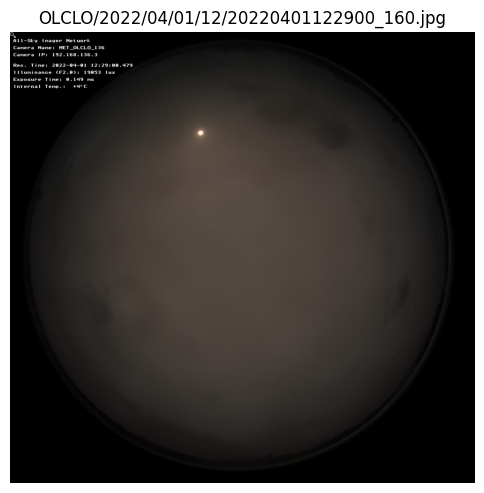

In [16]:
import zipfile
from PIL import Image
import matplotlib.pyplot as plt
from io import BytesIO

with zipfile.ZipFile("Eye2Sky/2022/04/01/ASI_20220401_OLCLO.zip", 'r') as z:
    # jpg 파일만 추출
    jpgs = [f for f in z.namelist() if f.endswith('.jpg')]
    print(f"총 이미지 수: {len(jpgs)}개")

    # 낮 시간대 이미지 하나 선택
    sample = [f for f in jpgs if '/12/' in f][0]
    print(f"샘플: {sample}")

    with z.open(sample) as f:
        img = Image.open(BytesIO(f.read()))

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(sample)
plt.axis('off')
plt.show()

In [17]:
from datetime import datetime
import re

# 파일명에서 타임스탬프 추출
# 예: 20220401122900_160.jpg → 2022-04-01 12:29:00
def parse_timestamp(filepath):
    fname = filepath.split('/')[-1]  # 20220401122900_160.jpg
    ts = fname.split('_')[0]         # 20220401122900
    return datetime.strptime(ts, "%Y%m%d%H%M%S")

# 테스트
with zipfile.ZipFile("Eye2Sky/2022/04/01/ASI_20220401_OLCLO.zip", 'r') as z:
    jpgs = [f for f in z.namelist() if f.endswith('.jpg')]
    for j in jpgs[:5]:
        dt = parse_timestamp(j)
        # OLWIN 데이터에서 해당 시간 GHI 찾기
        # 1분 단위로 반올림
        dt_min = dt.replace(second=0)
        ghi = df_day.loc[df_day.index == str(dt_min), 'GHI']
        kt = df_day.loc[df_day.index == str(dt_min), 'KT']
        print(f"{dt} → GHI: {ghi.values}, KT: {kt.values}")

2022-04-01 17:54:00 → GHI: [4.9], KT: [0.43272638]
2022-04-01 17:47:30 → GHI: [7.4], KT: [0.4130356]
2022-04-01 17:19:30 → GHI: [23.2], KT: [0.4126309]
2022-04-01 17:31:30 → GHI: [15.7], KT: [0.41996908]
2022-04-01 17:22:00 → GHI: [21.5], KT: [0.42013486]


In [18]:
import numpy as np
from PIL import Image
from io import BytesIO
import zipfile
import glob
from datetime import datetime
import pandas as pd

def parse_timestamp(filepath):
    fname = filepath.split('/')[-1]
    ts = fname.split('_')[0]
    return datetime.strptime(ts, "%Y%m%d%H%M%S")

def circular_mask(img_array):
    """전천 카메라 원형 마스크"""
    h, w = img_array.shape[:2]
    cx, cy = w // 2, h // 2
    r = min(cx, cy)
    Y, X = np.ogrid[:h, :w]
    mask = (X - cx)**2 + (Y - cy)**2 <= r**2
    return mask

def cloud_cover_rb(img_array, mask):
    """R/B ratio로 구름 픽셀 비율 계산"""
    R = img_array[:,:,0].astype(float)
    B = img_array[:,:,2].astype(float)

    with np.errstate(divide='ignore', invalid='ignore'):
        rb_ratio = np.where(B > 10, R / B, np.nan)

    # 구름: R/B > 0.95, 하늘: R/B <= 0.95
    sky_pixels = mask & (rb_ratio <= 0.95) & ~np.isnan(rb_ratio)
    cloud_pixels = mask & (rb_ratio > 0.95) & ~np.isnan(rb_ratio)
    total = sky_pixels.sum() + cloud_pixels.sum()

    if total == 0:
        return np.nan
    return cloud_pixels.sum() / total

# 전체 zip 처리
records = []
zip_files = sorted(glob.glob("Eye2Sky/**/*.zip", recursive=True))

for zf in zip_files:
    print(f"처리 중: {zf}")
    with zipfile.ZipFile(zf, 'r') as z:
        jpgs = [f for f in z.namelist() if f.endswith('.jpg')]
        for jpg in jpgs:
            dt = parse_timestamp(jpg)
            dt_min = dt.replace(second=0)

            row = df_day.loc[df_day.index == pd.Timestamp(dt_min)]
            if row.empty:
                continue

            with z.open(jpg) as f:
                img = np.array(Image.open(BytesIO(f.read())))

            mask = circular_mask(img)
            cc = cloud_cover_rb(img, mask)

            records.append({
                'timestamp': dt,
                'cloud_cover': cc,
                'GHI': row['GHI'].values[0],
                'cGHI': row['cGHI'].values[0],
                'KT': row['KT'].values[0],
                'SZA': row['SZA'].values[0],
            })

df_matched = pd.DataFrame(records)
print(f"\n완료! 총 {len(df_matched)}개 매칭")
print(df_matched.head())

처리 중: Eye2Sky/2022/04/01/ASI_20220401_OLCLO.zip
처리 중: Eye2Sky/2022/04/02/ASI_20220402_OLCLO.zip
처리 중: Eye2Sky/2022/04/03/ASI_20220403_OLCLO.zip
처리 중: Eye2Sky/2022/04/04/ASI_20220404_OLCLO.zip
처리 중: Eye2Sky/2022/04/05/ASI_20220405_OLCLO.zip

완료! 총 7769개 매칭
            timestamp  cloud_cover   GHI       cGHI        KT        SZA
0 2022-04-01 17:54:00     1.000000   4.9  11.323553  0.432726  89.578070
1 2022-04-01 17:47:30     0.373414   7.4  17.916131  0.413036  88.537084
2 2022-04-01 17:19:30     0.956825  23.2  56.224583  0.412631  84.352613
3 2022-04-01 17:31:30     0.973742  15.7  37.383705  0.419969  86.148640
4 2022-04-01 17:22:00     0.959841  21.5  51.174045  0.420135  84.801792


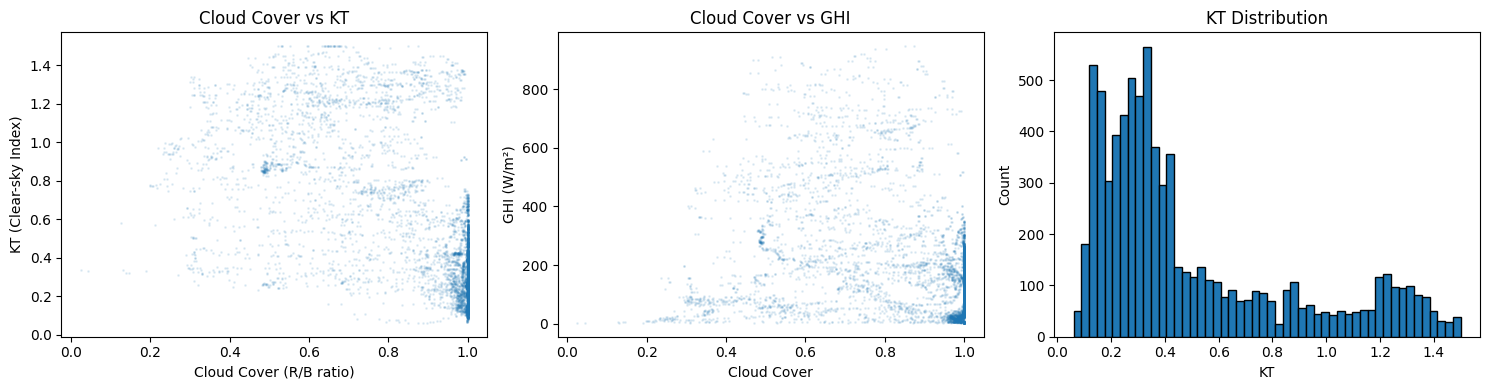

             cloud_cover       GHI        KT
cloud_cover     1.000000 -0.311140 -0.628479
GHI            -0.311140  1.000000  0.643298
KT             -0.628479  0.643298  1.000000


In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. 구름량 vs KT 산점도
axes[0].scatter(df_matched['cloud_cover'], df_matched['KT'], alpha=0.1, s=1)
axes[0].set_xlabel('Cloud Cover (R/B ratio)')
axes[0].set_ylabel('KT (Clear-sky Index)')
axes[0].set_title('Cloud Cover vs KT')

# 2. 구름량 vs GHI 산점도
axes[1].scatter(df_matched['cloud_cover'], df_matched['GHI'], alpha=0.1, s=1)
axes[1].set_xlabel('Cloud Cover')
axes[1].set_ylabel('GHI (W/m²)')
axes[1].set_title('Cloud Cover vs GHI')

# 3. KT 분포
axes[2].hist(df_matched['KT'], bins=50, edgecolor='black')
axes[2].set_xlabel('KT')
axes[2].set_ylabel('Count')
axes[2].set_title('KT Distribution')

plt.tight_layout()
plt.savefig('eda.png', dpi=150)
plt.show()

# 상관계수
corr = df_matched[['cloud_cover','GHI','KT']].corr()
print(corr)

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 결측치 제거
df_model = df_matched.dropna()

# 특성: cloud_cover + SZA (태양 고도 보정)
X = df_model[['cloud_cover', 'SZA', 'cGHI']].values
y = df_model['GHI'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"MAE:  {mean_absolute_error(y_test, y_pred):.2f} W/m²")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"\n특성 중요도:")
for feat, imp in zip(['cloud_cover', 'SZA', 'cGHI'], model.feature_importances_):
    print(f"  {feat}: {imp:.4f}")

MAE:  32.34 W/m²
R²:   0.9048

특성 중요도:
  cloud_cover: 0.4985
  SZA: 0.1800
  cGHI: 0.3216


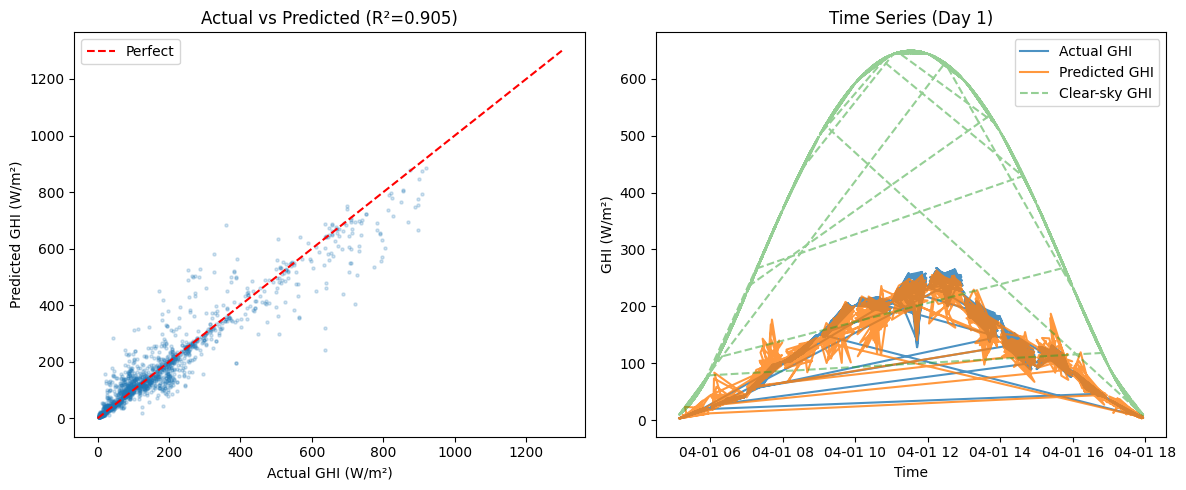

In [21]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. 예측 vs 실제
axes[0].scatter(y_test, y_pred, alpha=0.2, s=5)
axes[0].plot([0, 1300], [0, 1300], 'r--', label='Perfect')
axes[0].set_xlabel('Actual GHI (W/m²)')
axes[0].set_ylabel('Predicted GHI (W/m²)')
axes[0].set_title(f'Actual vs Predicted (R²={r2_score(y_test, y_pred):.3f})')
axes[0].legend()

# 2. 하루치 시계열
day = df_model[df_model['timestamp'].dt.date == df_model['timestamp'].dt.date.iloc[0]]
X_day = day[['cloud_cover', 'SZA', 'cGHI']].values
y_day_pred = model.predict(X_day)

axes[1].plot(day['timestamp'], day['GHI'], label='Actual GHI', alpha=0.8)
axes[1].plot(day['timestamp'], y_day_pred, label='Predicted GHI', alpha=0.8)
axes[1].plot(day['timestamp'], day['cGHI'], label='Clear-sky GHI', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('GHI (W/m²)')
axes[1].set_title('Time Series (Day 1)')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_result.png', dpi=150)
plt.show()

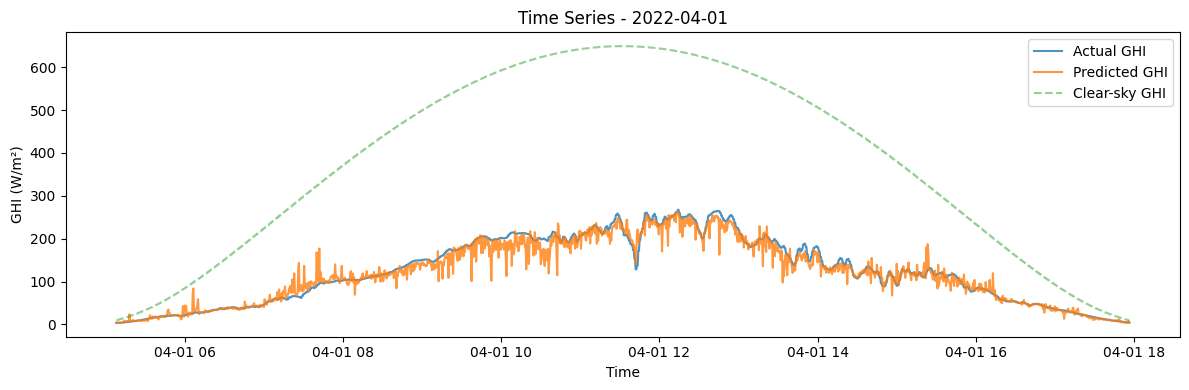

In [22]:
import matplotlib.pyplot as plt

# 날짜별로 하나씩 선택
target_date = df_model['timestamp'].dt.date.unique()[0]
day = df_model[df_model['timestamp'].dt.date == target_date].sort_values('timestamp')

X_day = day[['cloud_cover', 'SZA', 'cGHI']].values
y_day_pred = model.predict(X_day)

plt.figure(figsize=(12, 4))
plt.plot(day['timestamp'], day['GHI'], label='Actual GHI', alpha=0.8)
plt.plot(day['timestamp'], y_day_pred, label='Predicted GHI', alpha=0.8)
plt.plot(day['timestamp'], day['cGHI'], label='Clear-sky GHI', linestyle='--', alpha=0.5)
plt.xlabel('Time')
plt.ylabel('GHI (W/m²)')
plt.title(f'Time Series - {target_date}')
plt.legend()
plt.tight_layout()
plt.savefig('timeseries.png', dpi=150)
plt.show()

In [23]:
import numpy as np
from PIL import Image
from io import BytesIO
import zipfile
import glob
from datetime import datetime
import pandas as pd

IMG_SIZE = 128  # 리사이즈 크기

def parse_timestamp(filepath):
    fname = filepath.split('/')[-1]
    ts = fname.split('_')[0]
    return datetime.strptime(ts, "%Y%m%d%H%M%S")

def preprocess_image(img_array, size=IMG_SIZE):
    """원형 마스크 + 리사이즈 + 정규화"""
    img = Image.fromarray(img_array).resize((size, size))
    img = np.array(img) / 255.0  # 정규화

    # 원형 마스크
    h, w = img.shape[:2]
    cx, cy = w // 2, h // 2
    r = min(cx, cy)
    Y, X = np.ogrid[:h, :w]
    mask = ((X - cx)**2 + (Y - cy)**2 > r**2)
    img[mask] = 0  # 원 밖은 검정

    return img

# 전체 데이터 수집
images = []
tabular = []
targets = []

zip_files = sorted(glob.glob("Eye2Sky/**/*.zip", recursive=True))

for zf in zip_files:
    print(f"처리 중: {zf}")
    with zipfile.ZipFile(zf, 'r') as z:
        jpgs = [f for f in z.namelist() if f.endswith('.jpg')]
        for jpg in jpgs:
            dt = parse_timestamp(jpg)
            dt_min = dt.replace(second=0)
            row = df_day.loc[df_day.index == pd.Timestamp(dt_min)]
            if row.empty:
                continue

            with z.open(jpg) as f:
                img_array = np.array(Image.open(BytesIO(f.read())))

            img = preprocess_image(img_array)

            images.append(img)
            tabular.append([
                row['SZA'].values[0],
                row['cGHI'].values[0],
            ])
            targets.append(row['GHI'].values[0])

images  = np.array(images,  dtype=np.float32)
tabular = np.array(tabular, dtype=np.float32)
targets = np.array(targets, dtype=np.float32)

print(f"\n완료!")
print(f"images shape:  {images.shape}")
print(f"tabular shape: {tabular.shape}")
print(f"targets shape: {targets.shape}")

처리 중: Eye2Sky/2022/04/01/ASI_20220401_OLCLO.zip
처리 중: Eye2Sky/2022/04/02/ASI_20220402_OLCLO.zip
처리 중: Eye2Sky/2022/04/03/ASI_20220403_OLCLO.zip
처리 중: Eye2Sky/2022/04/04/ASI_20220404_OLCLO.zip
처리 중: Eye2Sky/2022/04/05/ASI_20220405_OLCLO.zip

완료!
images shape:  (7769, 128, 128, 3)
tabular shape: (7769, 2)
targets shape: (7769,)


In [24]:
import tensorflow as tf
from tensorflow.keras import layers, Model

IMG_SIZE = 128

def build_model():
    # 1. 이미지 입력 (MobileNetV2 backbone)
    img_input = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image')
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # 일단 freeze

    x = base_model(img_input, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)

    # 2. Tabular 입력 (SZA, cGHI)
    tab_input = tf.keras.Input(shape=(2,), name='tabular')
    t = layers.Dense(16, activation='relu')(tab_input)

    # 3. 합치기
    combined = layers.Concatenate()([x, t])
    combined = layers.Dense(32, activation='relu')(combined)
    output = layers.Dense(1, activation='linear', name='GHI')(combined)

    model = Model(inputs=[img_input, tab_input], outputs=output)
    return model

model = build_model()
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 4, 4,      │  2,257,984 │ image[0][0]       │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular             │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     81,984 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │         48 │ tabular[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,592 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ GHI (Dense)         │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,342,641 (8.94 MB)

 Trainable params: 84,657 (330.69 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 4, 4,      │  2,257,984 │ image[0][0]       │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular             │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │     81,984 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 16)        │         48 │ tabular[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 80)        │          0 │ dense_6[0][0],    │
│ (Concatenate)       │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │      2,592 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ GHI (Dense)         │ (None, 1)         │         33 │ dense_8[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,342,641 (8.94 MB)

 Trainable params: 84,657 (330.69 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Train: 5440개 | Val: 1163개 | Test: 1166개

[1차 학습] MobileNetV2 freeze 상태...
Epoch 1/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - loss: 0.0966 - mae: 0.0966 - mse: 0.0273 - val_loss: 0.0704 - val_mae: 0.0704 - val_mse: 0.0122 - learning_rate: 0.0010
Epoch 2/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0572 - mae: 0.0572 - mse: 0.0098 - val_loss: 0.0543 - val_mae: 0.0543 - val_mse: 0.0088 - learning_rate: 0.0010
Epoch 3/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0527 - mae: 0.0527 - mse: 0.0082 - val_loss: 0.0590 - val_mae: 0.0590 - val_mse: 0.0086 - learning_rate: 0.0010
Epoch 4/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0480 - mae: 0.0480 - mse: 0.0071 - val_loss: 0.0492 - val_mae: 0.0492 - val_mse: 0.0071 - learning_rate: 0.0010
Epoch 5/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0436 - mae: 0.0436 - mse: 0.0064 - val_loss: 0.0460 - val_mae: 0.0460 - val_mse: 0.0063 - learning_rate: 0.0010
Epoch 6/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/st

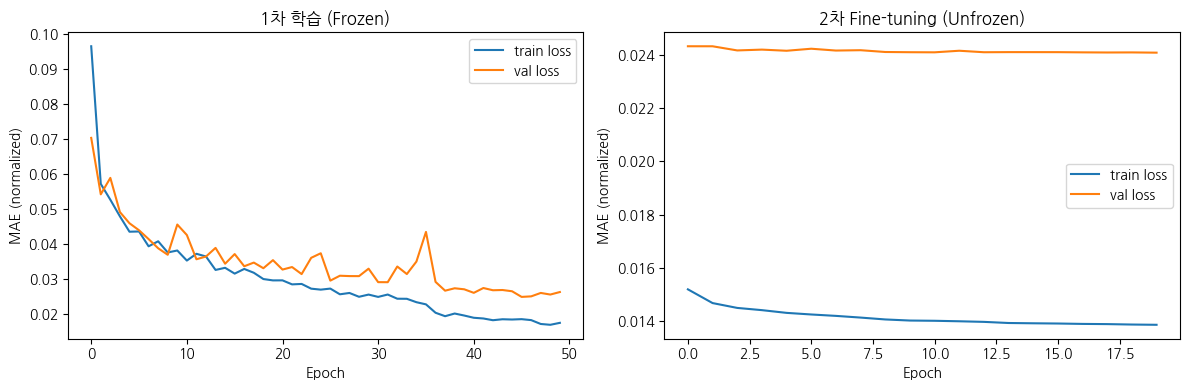

In [37]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# 셀 상단에 추가
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Colab 한글 폰트 설치
!apt-get install -y fonts-nanum > /dev/null
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

IMG_SIZE = 128

def build_model():
    img_input = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image')
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    x = base_model(img_input, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)

    tab_input = tf.keras.Input(shape=(2,), name='tabular')
    t = layers.Dense(16, activation='relu')(tab_input)

    combined = layers.Concatenate()([x, t])
    combined = layers.Dense(32, activation='relu')(combined)
    output = layers.Dense(1, activation='linear', name='GHI')(combined)

    model = Model(inputs=[img_input, tab_input], outputs=output)
    return model

model = build_model()
model.summary()

# ──────────────────────────────────────────
# ✅ 여기서부터 수정된 전체 학습 코드
# ──────────────────────────────────────────

# 1단계: numpy 변환
images  = np.array(images,  dtype=np.float32)
tabular = np.array(tabular, dtype=np.float32)
targets = np.array(targets, dtype=np.float32)

# GHI 정규화 (0~1)
ghi_max = targets.max()
targets_scaled = targets / ghi_max

# 2단계: Train / Val / Test split
X_img_trainval, X_img_test, X_tab_trainval, X_tab_test, y_trainval, y_test = train_test_split(
    images, tabular, targets_scaled,
    test_size=0.15, random_state=42
)
X_img_train, X_img_val, X_tab_train, X_tab_val, y_train, y_val = train_test_split(
    X_img_trainval, X_tab_trainval, y_trainval,
    test_size=0.176, random_state=42
)

# 3단계: Scaler — train만으로 fit
scaler = StandardScaler()
X_tab_train = scaler.fit_transform(X_tab_train)
X_tab_val   = scaler.transform(X_tab_val)
X_tab_test  = scaler.transform(X_tab_test)

print(f"Train: {len(y_train)}개 | Val: {len(y_val)}개 | Test: {len(y_test)}개")

# 4단계: 모델 컴파일
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mae',
    metrics=['mae', 'mse']
)

# 5단계: 콜백 정의
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        patience=5,
        factor=0.5,
        min_lr=1e-6
    )
]

# 6단계: 1차 학습 (backbone freeze 상태)
print("\n[1차 학습] MobileNetV2 freeze 상태...")
history = model.fit(
    {'image': X_img_train, 'tabular': X_tab_train},
    y_train,
    validation_data=(
        {'image': X_img_val, 'tabular': X_tab_val},
        y_val
    ),
    epochs=50,
    batch_size=32,
    callbacks=callbacks
)

# 7단계: Fine-tuning (backbone unfreeze)
print("\n[2차 학습] MobileNetV2 unfreeze fine-tuning...")
base_model = model.layers[2]  # MobileNetV2 레이어
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # lr 낮게!
    loss='mae',
    metrics=['mae', 'mse']
)

history_ft = model.fit(
    {'image': X_img_train, 'tabular': X_tab_train},
    y_train,
    validation_data=(
        {'image': X_img_val, 'tabular': X_tab_val},
        y_val
    ),
    epochs=20,
    batch_size=16,
    callbacks=callbacks
)

# 8단계: 테스트셋 최종 평가
y_pred_test = model.predict({'image': X_img_test, 'tabular': X_tab_test})
y_pred_test = y_pred_test.flatten() * ghi_max
y_true_test = y_test * ghi_max

mae  = np.mean(np.abs(y_pred_test - y_true_test))
rmse = np.sqrt(np.mean((y_pred_test - y_true_test)**2))
r2   = 1 - np.sum((y_true_test - y_pred_test)**2) / np.sum((y_true_test - y_true_test.mean())**2)

print(f"\n[Test 최종] MAE: {mae:.2f} W/m²  RMSE: {rmse:.2f} W/m²  R²: {r2:.4f}")

# 9단계: 학습 곡선 시각화
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1차 학습
axes[0].plot(history.history['loss'],     label='train loss')
axes[0].plot(history.history['val_loss'], label='val loss')
axes[0].set_title('1차 학습 (Frozen)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MAE (normalized)')
axes[0].legend()

# 2차 fine-tuning
axes[1].plot(history_ft.history['loss'],     label='train loss')
axes[1].plot(history_ft.history['val_loss'], label='val loss')
axes[1].set_title('2차 Fine-tuning (Unfrozen)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (normalized)')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curve.png', dpi=150)
plt.show()


In [38]:
import tensorflow as tf
import pickle

# 1. TFLite 변환
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# 2. 파일 저장
with open('ghi_model.tflite', 'wb') as f:
    f.write(tflite_model)
print(f"TFLite 모델 크기: {len(tflite_model) / 1024 / 1024:.2f} MB")

# 3. scaler, ghi_max 저장
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('ghi_max.pkl', 'wb') as f:
    pickle.dump(float(ghi_max), f)
print("scaler.pkl, ghi_max.pkl 저장 완료")

# 4. 다운로드
from google.colab import files
files.download('ghi_model.tflite')
files.download('scaler.pkl')
files.download('ghi_max.pkl')


Saved artifact at '/tmp/tmpepi7ynph'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='image'), TensorSpec(shape=(None, 2), dtype=tf.float32, name='tabular')]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134233948323280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233948318864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233948322320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233948318672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233948321552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233945002768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233945002960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233945008336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233944998736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233945011600: Tenso

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

모델 로드 완료!
ghi_max: 946.70 W/m²

테스트할 하늘 사진을 업로드하세요:


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Saving P0014.BMP to P0014.BMP

📷 P0014.BMP
   SZA  입력값: 45.0°
   cGHI 입력값: 600.0 W/m²
   ✅ 예측 GHI: 91.3 W/m²


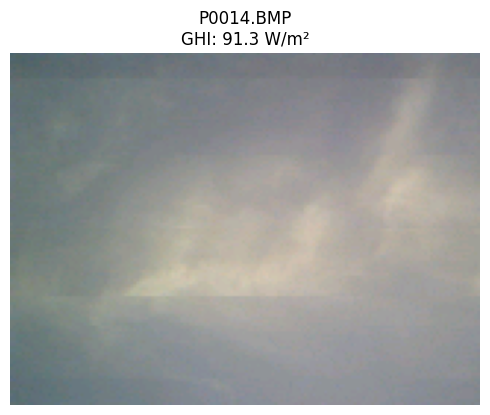

In [3]:
import numpy as np
import pickle
import tensorflow as tf
from PIL import Image
from io import BytesIO
from google.colab import files

# ──────────────────────────────────────────
# 1단계: 저장된 파일 로드
# ──────────────────────────────────────────
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('ghi_max.pkl', 'rb') as f:
    ghi_max = pickle.load(f)

interpreter = tf.lite.Interpreter(model_path='ghi_model.tflite')
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("모델 로드 완료!")
print(f"ghi_max: {ghi_max:.2f} W/m²")

# ──────────────────────────────────────────
# 2단계: 이미지 전처리 함수
# ──────────────────────────────────────────
def preprocess_image(img_source, size=128):
    """
    img_source: 파일 경로(str) 또는 PIL Image 또는 bytes
    """
    if isinstance(img_source, str):
        img = Image.open(img_source).convert('RGB')
    elif isinstance(img_source, bytes):
        img = Image.open(BytesIO(img_source)).convert('RGB')
    else:
        img = img_source.convert('RGB')

    img = img.resize((size, size))
    img = np.array(img, dtype=np.float32) / 255.0

    # 원형 마스크 (전천 카메라 원 밖 = 검정)
    h, w = img.shape[:2]
    cx, cy = w // 2, h // 2
    r = min(cx, cy)
    Y, X = np.ogrid[:h, :w]
    mask = ((X - cx)**2 + (Y - cy)**2 > r**2)
    img[mask] = 0

    return img[np.newaxis, ...]  # (1, 128, 128, 3)

# ──────────────────────────────────────────
# 3단계: 추론 함수
# ──────────────────────────────────────────
def predict_ghi(img_source, sza, cghi):
    """
    img_source : 이미지 경로 또는 PIL Image
    sza        : 태양 천정각 (Solar Zenith Angle, 도 단위)
    cghi       : 맑은날 이론 일사량 (W/m²)
    """
    img = preprocess_image(img_source)
    tab = scaler.transform([[sza, cghi]]).astype(np.float32)

    for inp in input_details:
        if 'image' in inp['name']:
            interpreter.set_tensor(inp['index'], img)
        elif 'tabular' in inp['name']:
            interpreter.set_tensor(inp['index'], tab)

    interpreter.invoke()
    pred = interpreter.get_tensor(output_details[0]['index'])[0][0] * ghi_max
    return float(pred)

# ──────────────────────────────────────────
# 4단계: 사진 업로드 & 추론
# ──────────────────────────────────────────
print("\n테스트할 하늘 사진을 업로드하세요:")
uploaded = files.upload()

for filename, data in uploaded.items():
    # SZA, cGHI 값 입력 (모르면 기본값 사용)
    sza  = 45.0   # ← 실제 촬영 시각의 태양 천정각으로 변경
    cghi = 600.0  # ← 해당 시각 맑은날 예상 일사량으로 변경

    ghi_pred = predict_ghi(data, sza=sza, cghi=cghi)
    print(f"\n📷 {filename}")
    print(f"   SZA  입력값: {sza}°")
    print(f"   cGHI 입력값: {cghi:.1f} W/m²")
    print(f"   ✅ 예측 GHI: {ghi_pred:.1f} W/m²")

# ──────────────────────────────────────────
# 5단계: 결과 시각화
# ──────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(uploaded), figsize=(5 * len(uploaded), 5))
if len(uploaded) == 1:
    axes = [axes]

for ax, (filename, data) in zip(axes, uploaded.items()):
    img = Image.open(BytesIO(data)).convert('RGB')
    ghi_pred = predict_ghi(data, sza=45.0, cghi=600.0)
    ax.imshow(img)
    ax.set_title(f"{filename}\nGHI: {ghi_pred:.1f} W/m²", fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig('test_result.png', dpi=150)
plt.show()


모델 로드 완료!
ghi_max: 946.70 W/m²

테스트할 하늘 사진을 업로드하세요:


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Saving P0012.BMP to P0012.BMP

📷 P0012.BMP
   SZA  입력값: 45.0°
   cGHI 입력값: 600.0 W/m²
   ✅ 예측 GHI: 154.1 W/m²


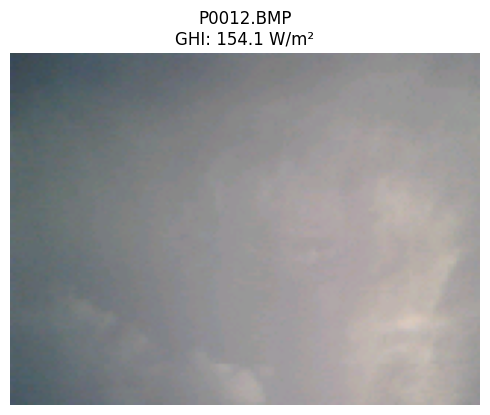

In [4]:
import numpy as np
import pickle
import tensorflow as tf
from PIL import Image
from io import BytesIO
from google.colab import files

# ──────────────────────────────────────────
# 1단계: 저장된 파일 로드
# ──────────────────────────────────────────
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('ghi_max.pkl', 'rb') as f:
    ghi_max = pickle.load(f)

interpreter = tf.lite.Interpreter(model_path='ghi_model.tflite')
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("모델 로드 완료!")
print(f"ghi_max: {ghi_max:.2f} W/m²")

# ──────────────────────────────────────────
# 2단계: 이미지 전처리 함수
# ──────────────────────────────────────────
def preprocess_image(img_source, size=128):
    """
    img_source: 파일 경로(str) 또는 PIL Image 또는 bytes
    """
    if isinstance(img_source, str):
        img = Image.open(img_source).convert('RGB')
    elif isinstance(img_source, bytes):
        img = Image.open(BytesIO(img_source)).convert('RGB')
    else:
        img = img_source.convert('RGB')

    img = img.resize((size, size))
    img = np.array(img, dtype=np.float32) / 255.0

    # 원형 마스크 (전천 카메라 원 밖 = 검정)
    h, w = img.shape[:2]
    cx, cy = w // 2, h // 2
    r = min(cx, cy)
    Y, X = np.ogrid[:h, :w]
    mask = ((X - cx)**2 + (Y - cy)**2 > r**2)
    img[mask] = 0

    return img[np.newaxis, ...]  # (1, 128, 128, 3)

# ──────────────────────────────────────────
# 3단계: 추론 함수
# ──────────────────────────────────────────
def predict_ghi(img_source, sza, cghi):
    """
    img_source : 이미지 경로 또는 PIL Image
    sza        : 태양 천정각 (Solar Zenith Angle, 도 단위)
    cghi       : 맑은날 이론 일사량 (W/m²)
    """
    img = preprocess_image(img_source)
    tab = scaler.transform([[sza, cghi]]).astype(np.float32)

    for inp in input_details:
        if 'image' in inp['name']:
            interpreter.set_tensor(inp['index'], img)
        elif 'tabular' in inp['name']:
            interpreter.set_tensor(inp['index'], tab)

    interpreter.invoke()
    pred = interpreter.get_tensor(output_details[0]['index'])[0][0] * ghi_max
    return float(pred)

# ──────────────────────────────────────────
# 4단계: 사진 업로드 & 추론
# ──────────────────────────────────────────
print("\n테스트할 하늘 사진을 업로드하세요:")
uploaded = files.upload()

for filename, data in uploaded.items():
    # SZA, cGHI 값 입력 (모르면 기본값 사용)
    sza  = 45.0   # ← 실제 촬영 시각의 태양 천정각으로 변경
    cghi = 600.0  # ← 해당 시각 맑은날 예상 일사량으로 변경

    ghi_pred = predict_ghi(data, sza=sza, cghi=cghi)
    print(f"\n📷 {filename}")
    print(f"   SZA  입력값: {sza}°")
    print(f"   cGHI 입력값: {cghi:.1f} W/m²")
    print(f"   ✅ 예측 GHI: {ghi_pred:.1f} W/m²")

# ──────────────────────────────────────────
# 5단계: 결과 시각화
# ──────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(uploaded), figsize=(5 * len(uploaded), 5))
if len(uploaded) == 1:
    axes = [axes]

for ax, (filename, data) in zip(axes, uploaded.items()):
    img = Image.open(BytesIO(data)).convert('RGB')
    ghi_pred = predict_ghi(data, sza=45.0, cghi=600.0)
    ax.imshow(img)
    ax.set_title(f"{filename}\nGHI: {ghi_pred:.1f} W/m²", fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig('test_result.png', dpi=150)
plt.show()


모델 로드 완료!
ghi_max: 946.70 W/m²

테스트할 하늘 사진을 업로드하세요:


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Saving P0016.BMP to P0016.BMP

📷 P0016.BMP
   SZA  입력값: 45.0°
   cGHI 입력값: 600.0 W/m²
   ✅ 예측 GHI: 234.5 W/m²


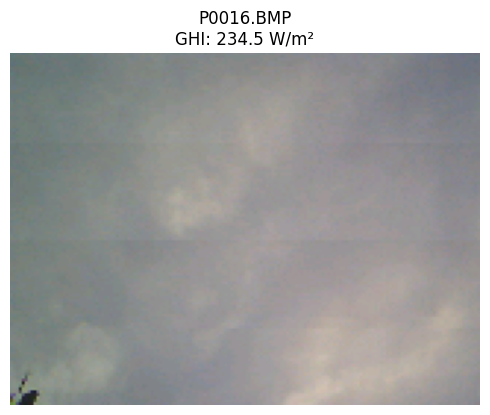

In [5]:
import numpy as np
import pickle
import tensorflow as tf
from PIL import Image
from io import BytesIO
from google.colab import files

# ──────────────────────────────────────────
# 1단계: 저장된 파일 로드
# ──────────────────────────────────────────
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('ghi_max.pkl', 'rb') as f:
    ghi_max = pickle.load(f)

interpreter = tf.lite.Interpreter(model_path='ghi_model.tflite')
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("모델 로드 완료!")
print(f"ghi_max: {ghi_max:.2f} W/m²")

# ──────────────────────────────────────────
# 2단계: 이미지 전처리 함수
# ──────────────────────────────────────────
def preprocess_image(img_source, size=128):
    """
    img_source: 파일 경로(str) 또는 PIL Image 또는 bytes
    """
    if isinstance(img_source, str):
        img = Image.open(img_source).convert('RGB')
    elif isinstance(img_source, bytes):
        img = Image.open(BytesIO(img_source)).convert('RGB')
    else:
        img = img_source.convert('RGB')

    img = img.resize((size, size))
    img = np.array(img, dtype=np.float32) / 255.0

    # 원형 마스크 (전천 카메라 원 밖 = 검정)
    h, w = img.shape[:2]
    cx, cy = w // 2, h // 2
    r = min(cx, cy)
    Y, X = np.ogrid[:h, :w]
    mask = ((X - cx)**2 + (Y - cy)**2 > r**2)
    img[mask] = 0

    return img[np.newaxis, ...]  # (1, 128, 128, 3)

# ──────────────────────────────────────────
# 3단계: 추론 함수
# ──────────────────────────────────────────
def predict_ghi(img_source, sza, cghi):
    """
    img_source : 이미지 경로 또는 PIL Image
    sza        : 태양 천정각 (Solar Zenith Angle, 도 단위)
    cghi       : 맑은날 이론 일사량 (W/m²)
    """
    img = preprocess_image(img_source)
    tab = scaler.transform([[sza, cghi]]).astype(np.float32)

    for inp in input_details:
        if 'image' in inp['name']:
            interpreter.set_tensor(inp['index'], img)
        elif 'tabular' in inp['name']:
            interpreter.set_tensor(inp['index'], tab)

    interpreter.invoke()
    pred = interpreter.get_tensor(output_details[0]['index'])[0][0] * ghi_max
    return float(pred)

# ──────────────────────────────────────────
# 4단계: 사진 업로드 & 추론
# ──────────────────────────────────────────
print("\n테스트할 하늘 사진을 업로드하세요:")
uploaded = files.upload()

for filename, data in uploaded.items():
    # SZA, cGHI 값 입력 (모르면 기본값 사용)
    sza  = 45.0   # ← 실제 촬영 시각의 태양 천정각으로 변경
    cghi = 600.0  # ← 해당 시각 맑은날 예상 일사량으로 변경

    ghi_pred = predict_ghi(data, sza=sza, cghi=cghi)
    print(f"\n📷 {filename}")
    print(f"   SZA  입력값: {sza}°")
    print(f"   cGHI 입력값: {cghi:.1f} W/m²")
    print(f"   ✅ 예측 GHI: {ghi_pred:.1f} W/m²")

# ──────────────────────────────────────────
# 5단계: 결과 시각화
# ──────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(uploaded), figsize=(5 * len(uploaded), 5))
if len(uploaded) == 1:
    axes = [axes]

for ax, (filename, data) in zip(axes, uploaded.items()):
    img = Image.open(BytesIO(data)).convert('RGB')
    ghi_pred = predict_ghi(data, sza=45.0, cghi=600.0)
    ax.imshow(img)
    ax.set_title(f"{filename}\nGHI: {ghi_pred:.1f} W/m²", fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig('test_result.png', dpi=150)
plt.show()
